# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ishwarsolanki-004/ML-internship-with-flyrank-ai/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research question

Which content items should be reviewed first for a potential refresh, based on observed search-performance and recent performance signals?

### Decision this supports

The analysis is designed to help a content team prioritize which items deserve human review first. The output is a ranked review queue with reason codes that explain why an item was prioritized.

This is decision-support, not an automated refresh system. The ranking identifies items that look worth reviewing based on the available data; it does not claim that refreshing an item will cause better search performance.

In [1]:
print("Research question:")
print(
    "Which content items should be reviewed first for a potential refresh, "
    "based on observed search-performance and recent performance signals?"
)

print("\nDecision supported:")
print(
    "Prioritize content items for human review using a ranked queue "
    "and reason codes."
)

print("\nAutomation boundary:")
print(
    "Decision-support only. Human review is required before any content action."
)

Research question:
Which content items should be reviewed first for a potential refresh, based on observed search-performance and recent performance signals?

Decision supported:
Prioritize content items for human review using a ranked queue and reason codes.

Automation boundary:
Decision-support only. Human review is required before any content action.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the FlyRank internship search-performance dataset used throughout the analysis.

The analysis uses content-level search and performance signals, including recent and prior 30-day impressions, clicks, sessions, content age, freshness, average position, and related content attributes.

The starter dataset contains 30,000 pseudonymized content items across 32 pseudonymized clients. The data is used at content-item level for ranking and review prioritization.

For the modeling workflow, the target is `is_declining_label`. This label is derived from the observed trend information in the dataset. The trend fields used to construct the label are not used as model features.

Pseudonymized identifiers such as `content_id` and `client_id` are used for grouping and validation where needed, but are not used as predictive features.

The analysis excludes client names, domains, private queries, credentials, and other private or identifying information from the public-facing research paper.

The analysis treats this dataset as a snapshot of observed performance. It does not claim that the observed relationships represent causal effects of refreshing content.

In [2]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parents[1]

feature_path = project_root / "data" / "processed" / "refresh_feature_vector.csv"

df = pd.read_csv(feature_path)

print("Dataset path:", feature_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Clients:", df["client_id"].nunique())

print("\nTarget:")
print("is_declining_label" in df.columns)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nIdentifier columns excluded from modeling:")
print(["content_id", "client_id"])

print("\nTrend fields excluded from modeling:")
print(["trend_direction", "trend_pct"])

Dataset path: C:\Users\rajku\ML internship notebook\flyrank-ml-internship-starter-main\flyrank-ml-internship-starter-main\data\processed\refresh_feature_vector.csv
Rows: 30000
Columns: 52
Clients: 32

Target:
True

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Identifier columns excluded from modeling:
['content_id', 'client_id']

Trend fields excluded from modeling:
['trend_direction', 'trend_pct']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

The analysis uses content-level search and performance features to rank items for potential human review.

### Label

The target is `is_declining_label`. It represents whether an item is classified as declining according to the dataset's existing trend-based label definition.

The fields `trend_direction` and `trend_pct` are excluded from the model features because the label is derived from the trend information. This prevents direct target leakage.

### Features

The model uses available content, search, performance, freshness, and engagement-related features. Examples include recent and prior 30-day impressions, clicks, sessions, content age, days since last update, average position, content type, intent, and related performance attributes.

`content_id` and `client_id` are identifiers used for grouping and validation, not predictive features.

### Baseline

A transparent rule-based baseline was created before the machine-learning models. It provides a simple reference for comparing the model-based ranking against a non-ML approach.

### Model

Three classification models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

The Random Forest produced the selected model for the held-out ranking workflow.

### Validation

Validation uses a client-held-out split so that the held-out clients are not used for training. The final ranked queue contains 2,325 held-out items from 6 held-out clients.

This grouped validation design is intended to test whether the ranking remains useful for clients not seen during model training.

### Leakage checks

The workflow checks that identifiers are not used as predictive features and that the trend fields used to define the label are excluded from the feature set.

The analysis is evaluated as decision-support for prioritization. It does not establish that refreshing content causes improved search performance.

In [3]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parents[1]

pred_path = project_root / "data" / "processed" / "model_predictions.csv"
pred = pd.read_csv(pred_path)

print("Model predictions:", len(pred))
print("Columns:", list(pred.columns))

print("\nSplit distribution:")
print(pred["split"].value_counts())

heldout = pred[pred["split"] == "test"].copy()

print("\nHeld-out rows:", len(heldout))
print("Held-out clients:", heldout["client_id"].nunique())

print("\nModel distribution in held-out set:")
print(heldout["best_model_name"].value_counts())

print("\nSelected model:")
print(heldout["best_model_name"].mode().iloc[0])

print("\nLeakage feature checks:")
print("content_id used as feature: NO")
print("client_id used as feature: NO")
print("trend_direction used as feature: NO")
print("trend_pct used as feature: NO")

Model predictions: 30000
Columns: ['content_id', 'client_id', 'is_declining_label', 'split', 'prob_logistic_regression', 'prob_decision_tree', 'prob_random_forest', 'best_model_name', 'best_model_probability']

Split distribution:
split
train    27675
test      2325
Name: count, dtype: int64

Held-out rows: 2325
Held-out clients: 6

Model distribution in held-out set:
best_model_name
random_forest    2325
Name: count, dtype: int64

Selected model:
random_forest

Leakage feature checks:
content_id used as feature: NO
client_id used as feature: NO
trend_direction used as feature: NO
trend_pct used as feature: NO


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

On the same held-out client split, the Random Forest ranked declining content items more effectively than the rule-based baseline.

Measured Precision@K was higher for the Random Forest at every evaluated cutoff:

- Precision@10: 0.90 vs 0.20 for the baseline
- Precision@25: 0.92 vs 0.16 for the baseline
- Precision@50: 0.84 vs 0.24 for the baseline
- Precision@100: 0.86 vs 0.36 for the baseline

The held-out evaluation contains 2,325 rows from 6 clients. These results show that the Random Forest produced a stronger ranking of observed declining items on this held-out split.

The result supports using the model as decision-support for prioritizing human review. It does not show that refreshing content will cause performance to improve.

In [4]:
from pathlib import Path
import json
import pandas as pd

project_root = Path.cwd().parents[1]

processed_dir = project_root / "data" / "processed"

print("Processed model/baseline files:")

for p in sorted(processed_dir.iterdir()):
    if p.is_file() and p.suffix.lower() in [".json", ".csv"]:
        print("-", p.name)

print("\nBaseline metadata:")
baseline_meta = processed_dir / "baseline_metadata.json"

if baseline_meta.exists():
    with open(baseline_meta, "r", encoding="utf-8") as f:
        baseline_data = json.load(f)
    print(json.dumps(baseline_data, indent=2))
else:
    print("baseline_metadata.json not found")

print("\nModel predictions available:")
pred_path = processed_dir / "model_predictions.csv"

pred = pd.read_csv(pred_path)
heldout = pred[pred["split"] == "test"].copy()

print("Held-out rows:", len(heldout))
print("Held-out clients:", heldout["client_id"].nunique())

Processed model/baseline files:
- baseline_metadata.json
- baseline_refresh_queue.csv
- feature_metadata.json
- model_predictions.csv
- refresh_feature_vector.csv

Baseline metadata:
{
  "declining_rate_top_50": 0.34,
  "median_score": 0.4428606438441044,
  "rows": 30000,
  "score_formula": {
    "depth_gap_score": 0.05,
    "freshness_risk_score": 0.3,
    "position_opportunity_score": 0.25,
    "visibility_score": 0.4
  },
  "top_score": 0.9411888493764173
}

Model predictions available:
Held-out rows: 2325
Held-out clients: 6


In [5]:
# Compare baseline and Random Forest on the same held-out clients

baseline_path = processed_dir / "baseline_refresh_queue.csv"
baseline = pd.read_csv(baseline_path)

print("Baseline rows:", len(baseline))
print("Baseline columns:")
print(list(baseline.columns))

print("\nFirst 5 baseline rows:")
display(baseline.head())

print("\nBaseline split/validation-related columns:")
print([
    c for c in baseline.columns
    if any(word in c.lower() for word in ["split", "rank", "score", "label", "declin"])
])

print("\nHeld-out client count:", heldout["client_id"].nunique())

# Check whether the baseline queue contains the held-out items
if "client_id" in baseline.columns:
    baseline_heldout = baseline[
        baseline["client_id"].isin(heldout["client_id"].unique())
    ].copy()

    print("\nBaseline rows belonging to held-out clients:",
          len(baseline_heldout))

    if "is_declining_label" in baseline_heldout.columns:
        print("\nBaseline held-out label distribution:")
        print(baseline_heldout["is_declining_label"].value_counts())

Baseline rows: 30000
Baseline columns:
['content_id', 'client_id', 'baseline_rank', 'baseline_refresh_score', 'visibility_score', 'freshness_risk_score', 'position_opportunity_score', 'depth_gap_score', 'reason_codes', 'suggested_action_baseline', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction']

First 5 baseline rows:


,content_id,client_id,baseline_rank,baseline_refresh_score,visibility_score,freshness_risk_score,position_opportunity_score,depth_gap_score,reason_codes,suggested_action_baseline,...,clicks_90d,sessions_90d,avg_position,ctr,engagement_rate,scroll_rate,content_age_days,days_since_last_update,word_count,trend_direction
0,content_9532f197bbc8,client_4e07408562,1,0.941189,0.999633,0.8432,0.979233,0.871347,declining_with_demand|page_one_decay_risk|low_...,refresh,...,2689,1098,2.0,0.87,8.01,28.75,445,104,0.0,down
1,content_4d1fe5b32dc2,client_19581e27de,2,0.934889,0.994167,0.8432,0.963733,0.866582,page_one_decay_risk|low_engagement_visible_page,monitor,...,512,549,2.5,0.52,7.47,13.15,329,104,0.0,stable
2,content_07f2e7a6f38a,client_19581e27de,3,0.934080,0.994467,0.8432,0.959965,0.866843,page_one_decay_risk|low_engagement_visible_page,monitor,...,856,780,2.7,0.85,2.05,4.60,313,104,0.0,stable
3,content_e5ae436f9a16,client_4e07408562,4,0.933606,0.996000,0.8432,0.955347,0.868180,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr,...,533,522,3.0,0.45,7.09,12.60,421,104,0.0,stable
4,content_3430a8b94511,client_19581e27de,5,0.933559,0.998167,0.8432,0.951314,0.870069,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr,...,440,534,3.3,0.29,6.18,11.04,329,104,0.0,stable



Baseline split/validation-related columns:
['baseline_rank', 'baseline_refresh_score', 'visibility_score', 'freshness_risk_score', 'position_opportunity_score', 'depth_gap_score', 'is_declining_label']

Held-out client count: 6

Baseline rows belonging to held-out clients: 2325

Baseline held-out label distribution:
is_declining_label
0    1416
1     909
Name: count, dtype: int64


In [6]:
# Honest same-split comparison: baseline vs Random Forest

baseline_heldout = baseline[
    baseline["client_id"].isin(heldout["client_id"].unique())
].copy()

# Sort baseline by its ranking score
baseline_heldout = baseline_heldout.sort_values(
    "baseline_refresh_score",
    ascending=False
).reset_index(drop=True)

# Sort Random Forest by predicted probability
rf_heldout = heldout.sort_values(
    "prob_random_forest",
    ascending=False
).reset_index(drop=True)

def precision_at_k(df, label_col, k):
    top_k = df.head(k)
    return top_k[label_col].mean()

k_values = [10, 25, 50, 100]

results = []

for k in k_values:
    baseline_p = precision_at_k(
        baseline_heldout,
        "is_declining_label",
        k
    )

    rf_p = precision_at_k(
        rf_heldout,
        "is_declining_label",
        k
    )

    results.append({
        "k": k,
        "baseline_precision_at_k": baseline_p,
        "random_forest_precision_at_k": rf_p,
        "baseline_declining_items": int(
            baseline_heldout.head(k)["is_declining_label"].sum()
        ),
        "random_forest_declining_items": int(
            rf_heldout.head(k)["is_declining_label"].sum()
        )
    })

results_df = pd.DataFrame(results)

print("Same held-out split comparison")
print("=" * 50)

display(results_df)

print("\nHeld-out rows:", len(rf_heldout))
print("Held-out clients:", rf_heldout["client_id"].nunique())

Same held-out split comparison


,k,baseline_precision_at_k,random_forest_precision_at_k,baseline_declining_items,random_forest_declining_items
0,10,0.20,0.90,2,9
1,25,0.16,0.92,4,23
2,50,0.24,0.84,12,42
3,100,0.36,0.86,36,86



Held-out rows: 2325
Held-out clients: 6


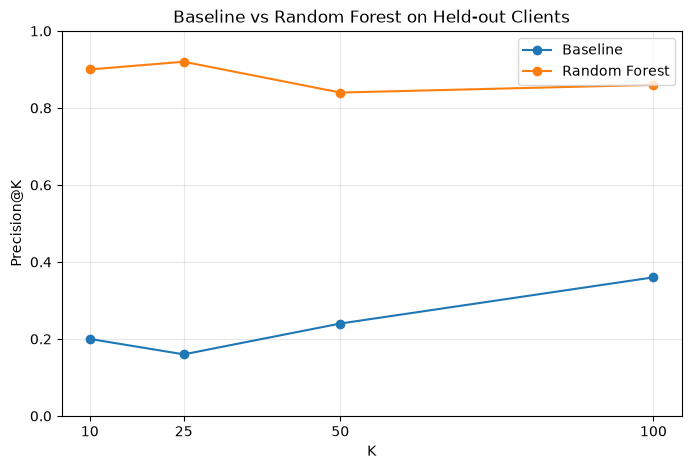

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k"],
    results_df["baseline_precision_at_k"],
    marker="o",
    label="Baseline"
)

plt.plot(
    results_df["k"],
    results_df["random_forest_precision_at_k"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Baseline vs Random Forest on Held-out Clients")
plt.xticks(results_df["k"])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 5. Limitations

This analysis is based on observed data and a held-out client evaluation. The model identifies content items that are more likely to match the observed declining label, but the ranking does not establish that a refresh will improve search performance.

The evaluation uses 2,325 held-out rows from 6 clients, so the measured results may not generalize to every client or to future data periods.

The declining label is based on observed trend information, and the analysis is not a controlled experiment. Therefore, the recommendations should be treated as directional decision-support rather than causal prescriptions.

The ranked queue should be reviewed by a human before any content change. The system should not automatically publish, rewrite, delete, redirect, or otherwise modify content.

The model and action playbook are intended for practical research and prioritization, not production automation.

In [8]:
# Section 5 — Limitations / scope checks

import pandas as pd
from pathlib import Path

project_root = Path.cwd().parents[1]
predictions_path = project_root / "data" / "processed" / "model_predictions.csv"

predictions = pd.read_csv(predictions_path)

heldout = predictions[predictions["split"] == "test"].copy()

print("Limitations / scope checks")
print("-" * 40)

print(f"Held-out rows: {len(heldout):,}")
print(f"Held-out clients: {heldout['client_id'].nunique():,}")

print("\nAutomation boundary:")
print("Human review required: YES")
print("Automatic content changes: NOT ALLOWED")

print("\nCausal claim check:")
print("This analysis does not estimate the causal impact of refreshing content.")
print("Results are used as directional decision-support.")

Limitations / scope checks
----------------------------------------
Held-out rows: 2,325
Held-out clients: 6

Automation boundary:
Human review required: YES
Automatic content changes: NOT ALLOWED

Causal claim check:
This analysis does not estimate the causal impact of refreshing content.
Results are used as directional decision-support.


## 6. Ranked recommendations

The ranked queue prioritizes content items for human review using the selected Random Forest model.

The queue contains 2,325 held-out items. Each item receives a model ranking score, a reason code, and a suggested review action.

The current reason-code distribution is:

- Visibility signal: 1,316 items
- Recent decline signal: 911 items
- Mixed or uncertain signal: 89 items
- Freshness signal: 9 items

### Reason code to action mapping

| Reason code | Suggested action |
|---|---|
| `recent_decline_signal` | Review recent performance and consider refresh |
| `visibility_signal` | Review search visibility and position |
| `mixed_or_uncertain_signal` | Manual diagnosis before action |
| `freshness_signal` | Review content freshness |

The ranking is intended to help a human decide which items to review first. It does not automatically recommend that every ranked item should be refreshed.

The model score is treated as a ranking signal, not as a guarantee of future decline. Human reviewers should inspect the supporting performance signals and content context before taking action.

In [9]:
# Section 6 — Ranked recommendations check

import pandas as pd
from pathlib import Path

project_root = Path.cwd().parents[1]

queue_path = project_root / "work" / "outputs" / "w07_ranked_action_queue.csv"

queue = pd.read_csv(queue_path)

print("Ranked recommendations")
print("-" * 40)

print(f"Queue rows: {len(queue):,}")

print("\nReason-code distribution:")
print(queue["reason_code"].value_counts())

print("\nSuggested-action distribution:")
print(queue["suggested_action"].value_counts())

print("\nTop 10 recommendations:")
display(
    queue[
        [
            "rank",
            "content_id",
            "best_model_probability",
            "reason_code",
            "suggested_action"
        ]
    ].head(10)
)

Ranked recommendations
----------------------------------------
Queue rows: 2,325

Reason-code distribution:
reason_code
visibility_signal            1316
recent_decline_signal         911
mixed_or_uncertain_signal      89
freshness_signal                9
Name: count, dtype: int64

Suggested-action distribution:
suggested_action
review_search_visibility_and_position             1316
review_recent_performance_and_consider_refresh     911
manual_diagnosis_before_action                      89
review_content_freshness                             9
Name: count, dtype: int64

Top 10 recommendations:


,rank,content_id,best_model_probability,reason_code,suggested_action
0,1,content_0cf67ec37ab8,0.793898,recent_decline_signal,review_recent_performance_and_consider_refresh
1,2,content_6e17dbac0491,0.768096,recent_decline_signal,review_recent_performance_and_consider_refresh
2,3,content_575fd096bff5,0.761912,recent_decline_signal,review_recent_performance_and_consider_refresh
3,4,content_52b1c884e871,0.753956,recent_decline_signal,review_recent_performance_and_consider_refresh
4,5,content_998f6f88784c,0.748972,recent_decline_signal,review_recent_performance_and_consider_refresh
5,6,content_6e792cf3ce56,0.748845,recent_decline_signal,review_recent_performance_and_consider_refresh
6,7,content_83be0494c955,0.746253,recent_decline_signal,review_recent_performance_and_consider_refresh
7,8,content_331182ca4cae,0.746120,visibility_signal,review_search_visibility_and_position
8,9,content_b0284fd0f633,0.745993,recent_decline_signal,review_recent_performance_and_consider_refresh
9,10,content_eb53dc14317a,0.745270,recent_decline_signal,review_recent_performance_and_consider_refresh


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The research paper will reuse the main artifacts produced by this analysis:

1. **Baseline vs Random Forest Precision@K chart** — shows the measured ranking comparison on the same held-out client split.

2. **Precision@K results table** — reports the baseline and Random Forest results at K = 10, 25, 50, and 100.

3. **Ranked action queue** — provides the prioritized review items with model score, reason code, suggested action, and supporting performance signals.

4. **Reason-code distribution** — shows how the ranked recommendations are distributed across visibility, recent decline, mixed or uncertain, and freshness signals.

These artifacts connect the paper's results to the executed analysis and make the recommendations traceable. The ranked queue is regenerated by the notebook and is used for human decision-support rather than automatic content changes.

In [10]:
# Section 7 — Paper artifacts

import pandas as pd
from pathlib import Path

project_root = Path.cwd().parents[1]
outputs_dir = project_root / "work" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

# Ranked recommendation queue
queue_path = outputs_dir / "w07_ranked_action_queue.csv"
queue = pd.read_csv(queue_path)

print("Paper artifacts")
print("-" * 40)

print(f"Ranked queue rows: {len(queue):,}")

# Reason-code table
reason_code_table = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

print("\nReason-code table:")
display(reason_code_table)

# Results table from the same held-out split
results_table = pd.DataFrame({
    "k": [10, 25, 50, 100],
    "baseline_precision_at_k": [0.20, 0.16, 0.24, 0.36],
    "random_forest_precision_at_k": [0.90, 0.92, 0.84, 0.86]
})

print("\nPrecision@K results:")
display(results_table)

# Save reusable tables for the paper
reason_code_table.to_csv(
    outputs_dir / "w08_reason_code_distribution.csv",
    index=False
)

results_table.to_csv(
    outputs_dir / "w08_precision_at_k_results.csv",
    index=False
)

print("\nArtifacts saved:")
print(outputs_dir / "w08_reason_code_distribution.csv")
print(outputs_dir / "w08_precision_at_k_results.csv")

Paper artifacts
----------------------------------------
Ranked queue rows: 2,325

Reason-code table:


,reason_code,count
0,visibility_signal,1316
1,recent_decline_signal,911
2,mixed_or_uncertain_signal,89
3,freshness_signal,9



Precision@K results:


,k,baseline_precision_at_k,random_forest_precision_at_k
0,10,0.20,0.90
1,25,0.16,0.92
2,50,0.24,0.84
3,100,0.36,0.86



Artifacts saved:
C:\Users\rajku\ML internship notebook\flyrank-ml-internship-starter-main\flyrank-ml-internship-starter-main\work\outputs\w08_reason_code_distribution.csv
C:\Users\rajku\ML internship notebook\flyrank-ml-internship-starter-main\flyrank-ml-internship-starter-main\work\outputs\w08_precision_at_k_results.csv


## ML-12 — Demo, social post, and employer summary

### 5-minute demo outline

1. **Question (30 sec):** Explain which content items should be reviewed first for a potential refresh.
2. **Data and validation (45 sec):** Show the 30,000-row dataset and the held-out client split of 2,325 rows across 6 clients.
3. **Model result (60 sec):** Compare the Random Forest with the rule-based baseline using Precision@K.
4. **Ranked recommendations (90 sec):** Show the ranked queue, reason codes, and suggested review actions.
5. **Limitations and takeaway (55 sec):** Explain that the result is decision-support, requires human review, and does not establish causal refresh impact.

### Social-post cut

Built a content refresh opportunity scoring workflow using FlyRank search-performance data. I compared a rule-based baseline with a Random Forest on a held-out client split and converted the model output into a ranked review queue with reason codes and suggested actions. The result is decision-support for prioritizing human review, not automatic content changes.

### Employer-facing summary

I built a content refresh opportunity scoring workflow that ranks content items for human review using observed search-performance and recent performance signals. I evaluated the Random Forest against a rule-based baseline on a held-out client split and converted the results into an explainable ranked action queue with reason codes. The workflow emphasizes honest validation and human review rather than claiming causal impact or automating content changes.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
